
# NeuralRetail – Demand Forecasting Notebook
## Prophet-Based Sales Forecasting Pipeline

### Project Phase
Forecasting Engine Development

### Objectives
This notebook:
- Loads processed retail data
- Builds daily sales forecasting dataset
- Performs time-series analysis
- Trains Prophet forecasting model
- Evaluates forecasting performance
- Visualizes future demand trends
- Saves trained forecasting model

### Business Goal
Predict future retail demand accurately for:
- Inventory Optimization
- Revenue Planning
- Seasonal Demand Management
- Stockout Reduction

---


# 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")


# 2. Load Processed Dataset

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,totalprice,total_amount,year,month,day,day_of_week,weekofyear,hour,year_month,log_quantity,log_total_amount
0,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,30.0,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.433987
1,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6,39.6,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.703768
2,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,30.0,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.433987
3,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6,30.6,2009,12,1,Tuesday,49,7,2009-12,2.564949,3.453157
4,489435,22195,HEART MEASURING SPOONS LARGE,24,2009-12-01 07:46:00,1.65,13085.0,United Kingdom,39.6,39.6,2009,12,1,Tuesday,49,7,2009-12,3.218876,3.703768


In [3]:

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)


Dataset Shape: (715863, 19)

Columns:
 Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country', 'totalprice', 'total_amount',
       'year', 'month', 'day', 'day_of_week', 'weekofyear', 'hour',
       'year_month', 'log_quantity', 'log_total_amount'],
      dtype='object')


In [4]:
# Schema validation – assert expected columns exist before proceeding
REQUIRED_COLS = [
    'invoicedate', 'total_amount', 'customerid',
    'quantity', 'unitprice',
]

missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(
        f"Missing columns: {missing}\n"
        f"Available: {df.columns.tolist()}\n"
        "Re-run the EDA notebook first to regenerate cleaned_retail_data.csv"
    )

print("Schema validation PASSED")
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")


Schema validation PASSED
Dataset: 715,863 rows x 19 cols


# 3. Datetime Processing

In [5]:

# Convert InvoiceDate

df['invoicedate'] = pd.to_datetime(df['invoicedate'])

print(df['invoicedate'].min())
print(df['invoicedate'].max())


2009-12-01 07:45:00
2011-12-09 12:50:00


# 4. Create Daily Sales Dataset

In [6]:
# Aggregate daily revenue
daily_sales = (
    df.groupby(df['invoicedate'].dt.date)['total_amount']
    .sum()
    .reset_index()
)

daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

# Sanity check – no dates with zero or negative revenue
assert (daily_sales['y'] > 0).all(), "Found non-positive revenue days – check data cleaning"

print(f"Daily time-series: {len(daily_sales)} days")
print(f"Date range       : {daily_sales['ds'].min().date()} to {daily_sales['ds'].max().date()}")
print(f"Revenue range    : {daily_sales['y'].min():,.2f} to {daily_sales['y'].max():,.2f}")
daily_sales.head()


Daily time-series: 604 days
Date range       : 2009-12-01 to 2011-12-09
Revenue range    : 2,099.45 to 34,294.39


,ds,y
0,2009-12-01,24471.05
1,2009-12-02,20745.38
2,2009-12-03,27562.37
3,2009-12-04,20156.46
4,2009-12-05,7016.16


In [7]:
# =========================================================
# Feature Engineering
# =========================================================

# Set ds as index for datetime operations
daily_sales = daily_sales.set_index('ds')

daily_sales['lag_1'] = daily_sales['y'].shift(1)

daily_sales['lag_7'] = daily_sales['y'].shift(7)

daily_sales['lag_14'] = daily_sales['y'].shift(14)

daily_sales['rolling_mean_7'] = (
    daily_sales['y']
    .rolling(7)
    .mean()
)

daily_sales['rolling_std_7'] = (
    daily_sales['y']
    .rolling(7)
    .std()
)

daily_sales['day_of_week'] = (
    daily_sales.index.dayofweek
)

daily_sales['month'] = (
    daily_sales.index.month
)

daily_sales['weekofyear'] = (
    daily_sales.index.isocalendar().week
)

daily_sales = daily_sales.dropna()

daily_sales.head()

,y,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,month,weekofyear
ds,,,,,,,,,
2009-12-16,20577.36,18357.06,21749.45,24471.05,17358.814286,2822.568440,2,12,51
2009-12-17,16354.27,20577.36,15049.58,20745.38,17545.198571,2684.359890,3,12,51
2009-12-18,13768.96,16354.27,18565.34,27562.37,16860.001429,2976.786619,4,12,51
2009-12-20,7200.33,13768.96,13556.17,20156.46,15952.024286,4650.995306,6,12,51
2009-12-21,4406.80,7200.33,14968.10,7016.16,14443.267143,6405.469070,0,12,52



## Business Insight

Daily aggregation transforms transactional retail data into a forecasting-ready time-series structure.
This enables future demand prediction and seasonal trend analysis.


# 5. Time-Series Visualization

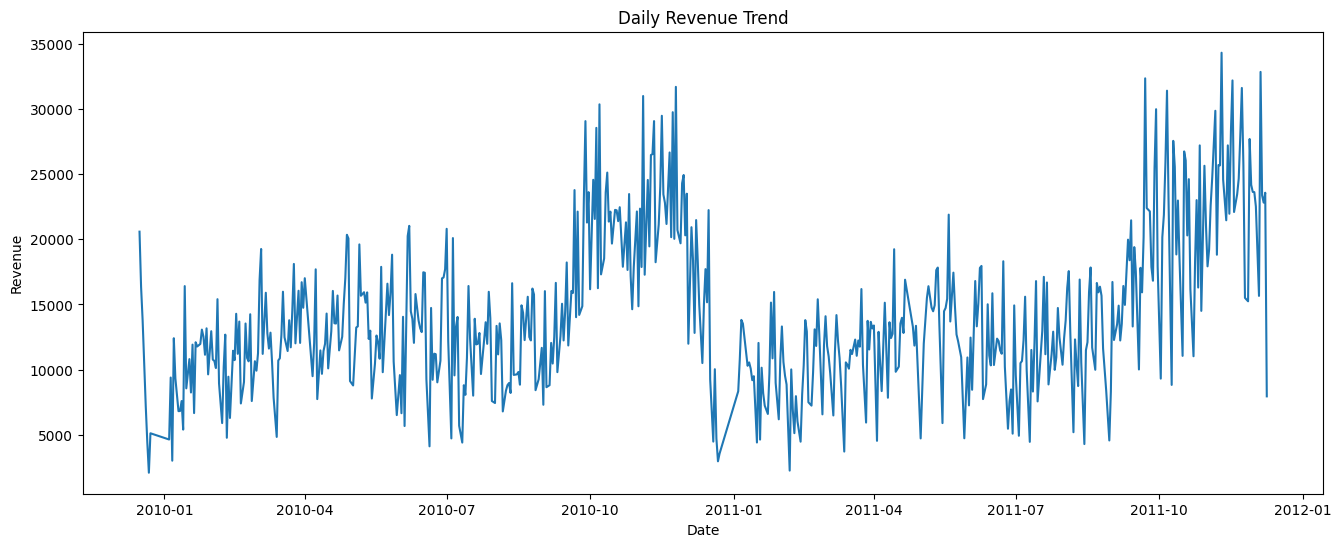

In [8]:
plt.figure(figsize=(16,6))

plt.plot(daily_sales.index, daily_sales['y'])

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.show()


## Business Insight

Revenue fluctuations indicate strong seasonality and demand variation.
These patterns are valuable for:
- Inventory planning
- Promotional campaigns
- Forecast-based replenishment


# 6. Train-Test Split

In [9]:
# 80-20 split
# Reset index to get 'ds' column back for Prophet
daily_sales_reset = daily_sales.reset_index()

split_index = int(len(daily_sales_reset) * 0.8)

train = daily_sales_reset[['ds', 'y']][:split_index]
test = daily_sales_reset[['ds', 'y']][split_index:]

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (472, 2)
Test Shape: (118, 2)


# 7. Prophet Model Training

In [10]:

# Initialize Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train model
model.fit(train)

print("Prophet model trained successfully.")


13:36:30 - cmdstanpy - INFO - Chain [1] start processing
13:36:32 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


# 8. Future Forecast Generation

In [11]:

# Generate future dataframe

future = model.make_future_dataframe(
    periods=len(test),
    freq='D'
)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()


,ds,yhat,yhat_lower,yhat_upper
0,2009-12-16,12236.115168,8073.566409,16369.160852
1,2009-12-17,14556.040573,10835.078501,18388.805598
2,2009-12-18,8746.985503,5008.199693,12287.774678
3,2009-12-20,7393.898029,3438.566320,11049.938078
4,2009-12-21,9250.244323,5623.246967,12959.186974


# 9. Forecast Visualization

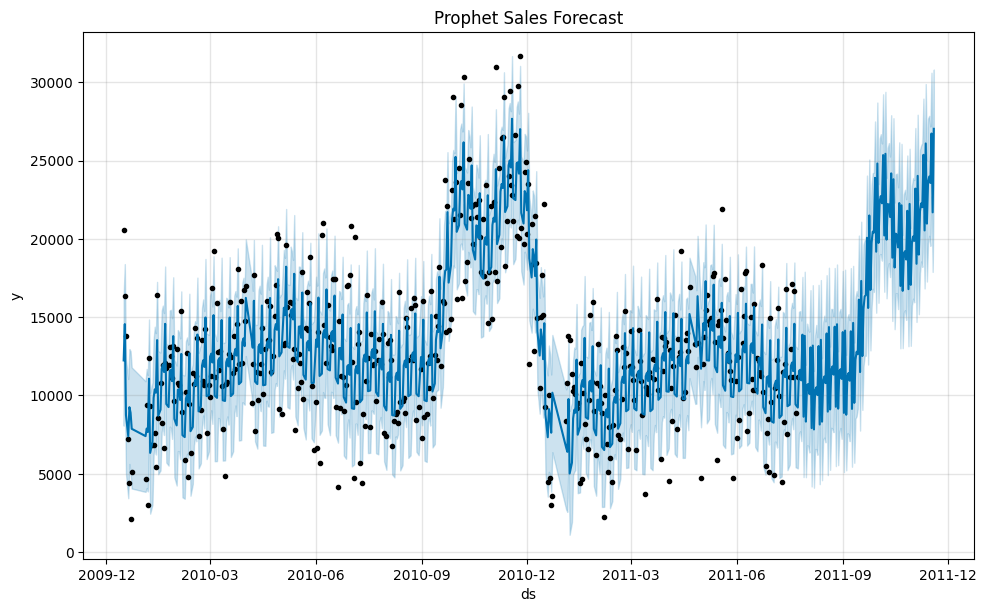

In [12]:

# Forecast plot

fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.show()


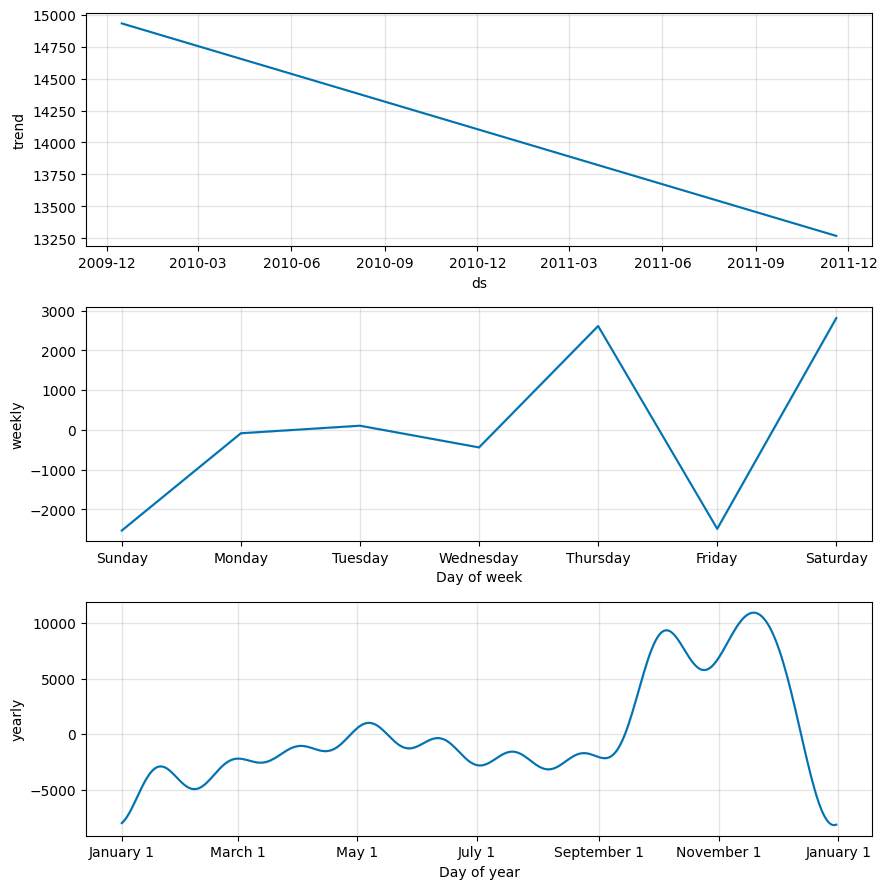

In [13]:

# Prophet components

fig2 = model.plot_components(forecast)

plt.show()



## Business Insight

Prophet automatically captures:
- Trend
- Weekly seasonality
- Long-term demand movement

These insights help retail businesses optimize:
- Reorder cycles
- Staffing
- Marketing timing


# 10. Forecast Evaluation

In [14]:
# Forecast evaluation
predictions = forecast[['ds', 'yhat']].tail(len(test)).reset_index(drop=True)
test_reset  = test.reset_index(drop=True)

actual    = test_reset['y'].values
predicted = predictions['yhat'].values

# Core metrics
prophet_mape = mean_absolute_percentage_error(actual, predicted)
rmse = float(np.sqrt(mean_squared_error(actual, predicted)))
mae  = float(np.mean(np.abs(actual - predicted)))

# Directional accuracy (did we get the up/down direction right?)
actual_dir    = np.sign(np.diff(actual))
predicted_dir = np.sign(np.diff(predicted))
dir_accuracy  = float(np.mean(actual_dir == predicted_dir))

print('Prophet Forecast Evaluation')
print(f'  MAPE              : {prophet_mape*100:.2f}%  (target <= 10%)')
print(f'  RMSE              : {rmse:,.2f}')
print(f'  MAE               : {mae:,.2f}')
print(f'  Directional Acc   : {dir_accuracy*100:.1f}%')

# Spec gate
status = 'PASSED' if prophet_mape <= 0.10 else 'NEEDS IMPROVEMENT'
print(f'\nMAPE target (<= 10%): {status}')
if prophet_mape > 0.10:
    print('  -> Consider: Optuna HPO for changepoint_prior_scale / seasonality_mode')
    print('  -> Consider: Adding exogenous regressors (promotions, holidays)')
    print('  -> Consider: Prophet + LSTM ensemble (next notebook)')


Prophet Forecast Evaluation
  MAPE              : 30.75%  (target <= 10%)
  RMSE              : 6,464.50
  MAE               : 5,020.94
  Directional Acc   : 48.7%

MAPE target (<= 10%): NEEDS IMPROVEMENT
  -> Consider: Optuna HPO for changepoint_prior_scale / seasonality_mode
  -> Consider: Adding exogenous regressors (promotions, holidays)
  -> Consider: Prophet + LSTM ensemble (next notebook)


In [15]:
# =========================================================
# XGBoost Forecasting
# =========================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_std_7',
    'day_of_week',
    'month',
    'weekofyear'
]

# Use the reset data to align with feature indices
X = daily_sales_reset[features].iloc[split_index:]  # Get corresponding rows for features
X = daily_sales[features]

y = daily_sales['y']

split_index = int(len(daily_sales) * 0.8)

X_train = X.iloc[:split_index]

X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]

y_test = y.iloc[split_index:]

xgb_forecast_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_forecast_model.fit(
    X_train,
    y_train
)

xgb_preds = xgb_forecast_model.predict(
    X_test
)

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_preds
)

print(f"XGBoost MAPE: {xgb_mape*100:.2f}%")

XGBoost MAPE: 21.45%


In [16]:
# =========================================================
# Forecast Model Comparison
# =========================================================

comparison_df = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost'],
    'MAPE (%)': [round(prophet_mape*100, 2), round(xgb_mape*100, 2)]
}).sort_values(by='MAPE (%)')

print("\n" + "="*50)
print("FORECAST MODEL COMPARISON")
print("="*50)
print(comparison_df.to_string(index=False))
print("="*50)
print(f"\n🏆 Best Model: {comparison_df.iloc[0]['Model']} (MAPE: {comparison_df.iloc[0]['MAPE (%)']}%)")


FORECAST MODEL COMPARISON
  Model  MAPE (%)
XGBoost     21.45
Prophet     30.75

🏆 Best Model: XGBoost (MAPE: 21.45%)



## Evaluation Interpretation

Lower MAPE indicates better forecasting accuracy.

Project Target:
- MAPE ≤ 10%

This metric directly measures forecasting performance quality.


# 11. Save Forecast Results

In [17]:

# Create folders
os.makedirs("../output/models", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

# Save forecast results
forecast.to_csv(
    "../data/exports/forecast_results.csv",
    index=False
)

# Save trained model
with open("../output/models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Forecast outputs saved successfully.")


Forecast outputs saved successfully.


# 12. Future 30-Day Forecast

In [18]:

future_30 = model.make_future_dataframe(
    periods=30,
    freq='D'
)

forecast_30 = model.predict(future_30)

forecast_30[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(30)


,ds,yhat,yhat_lower,yhat_upper
472,2011-07-25,11566.981885,7892.887697,15159.678059
473,2011-07-26,11637.635673,7774.487651,15808.567440
474,2011-07-27,10962.585721,7189.082617,14538.436581
475,2011-07-28,13880.552497,10030.587196,17655.489255
476,2011-07-29,8640.460806,4929.357544,12665.398781
477,2011-07-30,13806.001825,9774.354819,17411.819578
478,2011-07-31,8328.525524,4368.702158,12059.621503
479,2011-08-01,10652.680596,6778.519883,14376.248823
480,2011-08-02,10732.289478,7073.553857,14734.575831
481,2011-08-03,10092.333819,6387.608874,13710.757128


In [23]:
# =========================================================
# Export Forecast Results
# =========================================================

forecast = df.reset_index()

forecast_export = forecast

forecast_export.tail(500).to_csv(

    r"D:\NuralRetail\app\dashboard\data\forecast_results.csv", index=False

    
)

print("✅ forecast_results.csv exported successfully")

✅ forecast_results.csv exported successfully



## Business Recommendation

The generated forecasts can now support:
- Inventory optimization
- Revenue planning
- Safety stock calculation
- Promotion scheduling
- Demand intelligence dashboards



# Final Conclusion

This notebook successfully:
- Built a forecasting-ready dataset
- Trained Prophet demand forecasting model
- Generated future sales predictions
- Evaluated forecasting quality
- Saved forecasting artifacts


## NeuralRetail – Amdox Technologies

